<a href="https://colab.research.google.com/github/Minetriforce/DL_project_traffic_signs/blob/main/project_traffic_signs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Partie 1 — Recherche, compréhension et préparation des données**

## **Description du dataset**


**GTSRB — German Traffic Sign Recognition Benchmark**

| Élément | Valeur |
|---|---|
| Source officielle | Institut für Neuroinformatik (INI), Ruhr-Universität Bochum : https://benchmark.ini.rub.de/ |
| Copie utilisée | Kaggle : https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign |
| Auteurs / référence | J. Stallkamp, M. Schlipsing, J. Salmen, C. Igel, *Man vs. computer: Benchmarking machine learning algorithms for traffic sign recognition*, Neural Networks, 2012 |
| Origine | Photos réelles de panneaux allemands, extraites de séquences vidéo prises sur route |
| Nombre de classe | 43 |
| Taille | 39 209 images d'entraînement + 12 630 images de test (≈ 51 800 au total) |
| Format | Images couleur RGB, fichiers `.png` (copie Kaggle), avec des CSV d'annotations (taille, zone du panneau, classe) |
| Dimensions | Variables : d'environ 15×15 à 250×250 pixels |
| Licence | Creative Commons Attribution 4.0 International (CC-BY-4.0)


**Pourquoi ce choix ?** Dataset de référence, bien documenté, assez grand pour entraîner un CNN, avec de vraies difficultés
(luminosité, flou, petite taille, classes proches comme les limitations de vitesse) qui nourriront les parties 5 et 6.

In [1]:
import kagglehub
import os
import matplotlib.pyplot as plt

#kagglehub.login()
DATA_PATH = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(DATA_PATH)
print(os.listdir(DATA_PATH))


Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
/kaggle/input/gtsrb-german-traffic-sign
['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [2]:
DATA_PATH_TRAIN = os.path.join(DATA_PATH, 'Train')
DATA_PATH_TEST = os.path.join(DATA_PATH, 'Test')
DATA_PATH_META = os.path.join(DATA_PATH, 'Meta')

print(DATA_PATH_TRAIN)
print(DATA_PATH_TEST)
print(DATA_PATH_META)
NUM_CLASSES = 43
IMG_SIZE = 32 # Redimensionnement standard

CLASSES = {
 0:"Limitation 20 km/h", 1:"Limitation 30 km/h", 2:"Limitation 50 km/h", 3:"Limitation 60 km/h",
 4:"Limitation 70 km/h", 5:"Limitation 80 km/h", 6:"Fin de limitation 80 km/h", 7:"Limitation 100 km/h",
 8:"Limitation 120 km/h", 9:"Interdiction de dépasser", 10:"Interdiction de dépasser (camions)",
 11:"Intersection avec priorité", 12:"Route prioritaire", 13:"Cédez le passage", 14:"STOP",
 15:"Circulation interdite", 16:"Interdit aux camions", 17:"Sens interdit", 18:"Danger général",
 19:"Virage dangereux à gauche", 20:"Virage dangereux à droite", 21:"Succession de virages",
 22:"Cassis ou dos-d'âne", 23:"Chaussée glissante", 24:"Chaussée rétrécie (droite)", 25:"Travaux",
 26:"Feux tricolores", 27:"Passage piétons", 28:"Enfants", 29:"Cyclistes", 30:"Verglas / neige",
 31:"Animaux sauvages", 32:"Fin de toutes interdictions", 33:"Obligation : à droite",
 34:"Obligation : à gauche", 35:"Obligation : tout droit", 36:"Obligation : tout droit ou droite",
 37:"Obligation : tout droit ou gauche", 38:"Contourner l'obstacle par la droite", 39:"Contourner l'obstacle par la gauche",
 40:"Rond-point", 41:"Fin interdiction de dépasser", 42:"Fin interdiction de dépasser (camions)"}

print("Nombre de classes : ", NUM_CLASSES)

/kaggle/input/gtsrb-german-traffic-sign/Train
/kaggle/input/gtsrb-german-traffic-sign/Test
/kaggle/input/gtsrb-german-traffic-sign/Meta
Nombre de classes :  43


0    | Limitation 20 km/h                       | 210
1    | Limitation 30 km/h                       | 2220
2    | Limitation 50 km/h                       | 2250
3    | Limitation 60 km/h                       | 1410
4    | Limitation 70 km/h                       | 1980
5    | Limitation 80 km/h                       | 1860
6    | Fin de limitation 80 km/h                | 420
7    | Limitation 100 km/h                      | 1440
8    | Limitation 120 km/h                      | 1410
9    | Interdiction de dépasser                 | 1470
10   | Interdiction de dépasser (camions)       | 2010
11   | Intersection avec priorité               | 1320
12   | Route prioritaire                        | 2100
13   | Cédez le passage                         | 2160
14   | STOP                                     | 780
15   | Circulation interdite                    | 630
16   | Interdit aux camions                     | 420
17   | Sens interdit                            | 1110
18   | Danger g

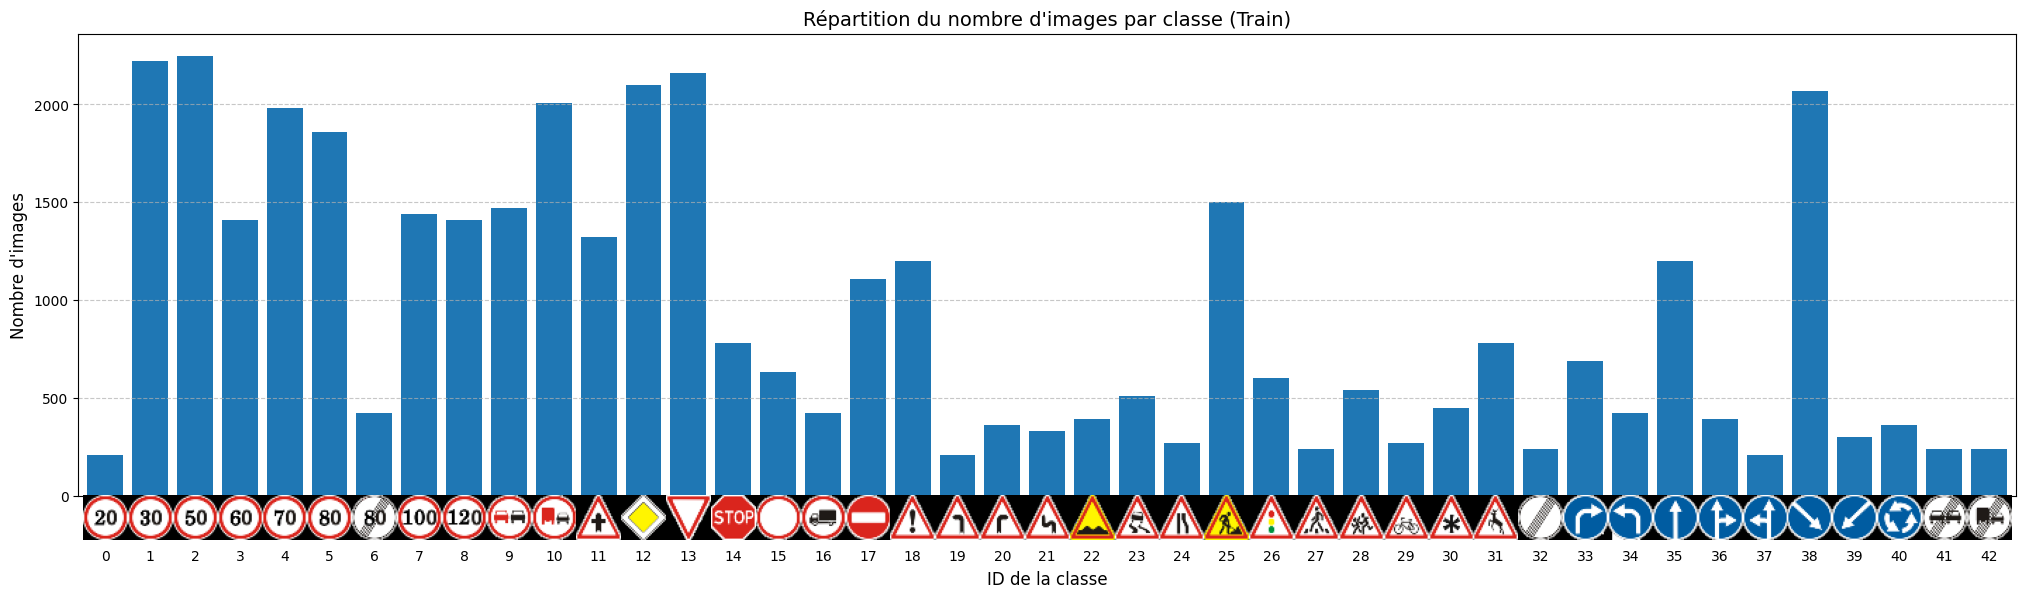

In [3]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

image_counts = {}
reference_images = {}

for class_id in range(NUM_CLASSES):
    folder_path = os.path.join(DATA_PATH_TRAIN, str(class_id))
    icon_path = os.path.join(DATA_PATH_META, f"{class_id}.png")

    if os.path.isdir(folder_path):
        num_images = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
        image_counts[class_id] = num_images

        class_name = CLASSES[class_id]
        print(f"{class_id:<4} | {class_name:<40} | {num_images}")

        # Chargement de l'icône de référence depuis le dossier Meta
        if os.path.exists(icon_path):
            img = cv2.imread(icon_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_icon = cv2.resize(img, (32, 32))
            reference_images[class_id] = img_icon
        else:
          print("Problème avec le chemin de fichiers vers les icônes")
    else:
        print("Problème avec le chemin de fichiers de la base de test")

print('\n')


# Histogramme
plt.figure(figsize=(25, 6))
ax = plt.gca() # Récupère l'axe actuel pour manipuler les icônes
ax.bar(image_counts.keys(), image_counts.values())
ax.set_title("Répartition du nombre d'images par classe (Train)", fontsize=14)
ax.set_xlabel("ID de la classe", fontsize=12, labelpad=5) # labelpad éloigne le titre de l'axe pour faire de la place
ax.set_ylabel("Nombre d'images", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
# Configuration de l'axe X pour afficher les numéros
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(range(NUM_CLASSES))
# décale les numéros vers le bas pour glisser l'image au-dessus
ax.tick_params(axis='x', pad=35)
ax.set_xlim(-0.6, NUM_CLASSES - 0.4) # réduit les marges latérales

# Placement des icônes du dossier Meta
for class_id in range(NUM_CLASSES):
    if class_id in reference_images:
        imagebox = OffsetImage(reference_images[class_id], zoom=1)
        # xybox=(0, -16) positionne l'image juste sous la ligne zéro, au-dessus du chiffre
        ab = AnnotationBbox(imagebox, (class_id, 0),
                            xybox=(0, -16),
                            xycoords='data',
                            boxcoords="offset points",
                            frameon=False)
        ax.add_artist(ab)

plt.show()

On peut observer un grand déséquilibre entre les classes, par exemple il y a 10 fois plus de limitations de vitesse à 50km qu'il n'y en a pour 20km

## **Préparation des données**

Dans un premier temps, nous allons parcourir l'ensemble des images contenus dans le fichier Train afin d'en tirer une liste d'images et une liste de lablel.
Ce parcours va également nous permettre de normaliser les pixels et redimensionner chaque images.
Pour le redimensionnemnet, nous avons choisis une taille de 32x32 pixels car c'était le meilleur compris, assez proche de la dimension médiane, qui n'allait pas trop déformer les images avec des dimensions extrêmes.

Chargement des images depuis /kaggle/input/gtsrb-german-traffic-sign/Train...


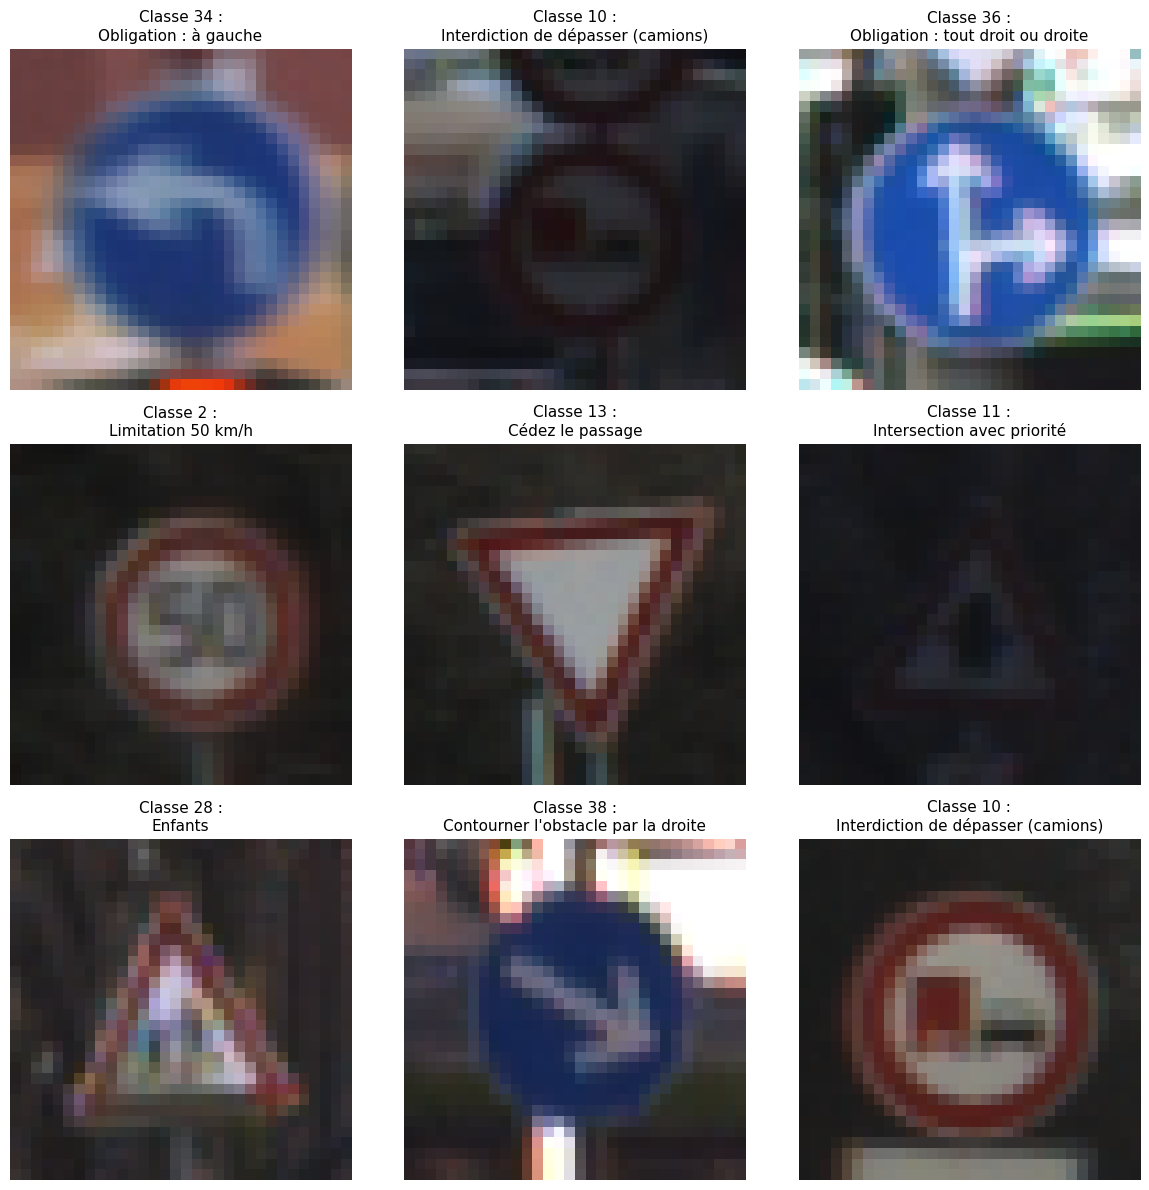

In [4]:
import numpy as np

images = []
labels = []

print(f"Chargement des images depuis {DATA_PATH_TRAIN}...")
for class_id in range(NUM_CLASSES):
    folder_path = os.path.join(DATA_PATH_TRAIN, str(class_id))

    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            if img_name.endswith('.png'):
                img_path = os.path.join(folder_path, img_name)
                img = cv2.imread(img_path)

                if img is not None:
                    # Conversion BGR (OpenCV) vers RGB (Standard)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    # Redimensionnement
                    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    images.append(img_resized)
                    labels.append(class_id)

images = np.array(images)
labels = np.array(labels)

# Normalisation des pixels par division par 255
images = images.astype('float32') / 255.0

# Affichage d'une grille de 9 images aléatoires
plt.figure(figsize=(12, 12))

# On génère 9 indices aléatoires pour piocher dans le dataset
for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Choix d'une image au hasard dans la liste globale 'images'
    idx = np.random.randint(0, len(images))

    # Affichage de l'image
    plt.imshow(images[idx])

    # Récupération de l'ID et du nom de la classe
    class_id = labels[idx]
    class_name = CLASSES[class_id]

    # Titre avec le numéro et le texte
    plt.title(f"Classe {class_id} :\n{class_name}", fontsize=11)
    plt.axis('off') # On masque les axes pour faire plus propre

plt.tight_layout()
plt.show()

Le morceau de code qui suis correspond à la séparation des données d'entrainement en un ensemble d'entrainement et un ensemble de validation grâce à la fonciont train_test_split de sklearn.

In [5]:
from sklearn.model_selection import train_test_split

#génération des ensembles de train et de validation
X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.20,
    random_state=42
)

print(f"Entraînement : {X_train.shape} | Labels : {y_train.shape}")
print(f"Validation   : {X_val.shape} | Labels : {y_val.shape}")

Entraînement : (31367, 32, 32, 3) | Labels : (31367,)
Validation   : (7842, 32, 32, 3) | Labels : (7842,)


# **Partie 3 — Construction d'un CNN avec Keras**

## **Choix de l'architecture**

L'architecture choisie est un réseau de neurones convolutif (CNN) adapté à la classification d'images. L'image d'entrée possède une taille de **32 × 32 pixels avec 3 canaux de couleur (RGB)**. Le réseau est composé de trois blocs convolution + ReLU + MaxPooling, suivis d'une couche Flatten, d'une couche Dense de 128 neurones et d'une couche de sortie de 43 neurones.

Image 32×32×3  
 --> Conv2D(32, 3×3, same) + ReLU → MaxPooling 2×2  
 --> Conv2D(64, 3×3, same) + ReLU → MaxPooling 2×2  
 --> Conv2D(128, 3×3, same) + ReLU → MaxPooling 2×2  
 --> Flatten → Dense(128) + ReLU → Dense(43) + Softmax  

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
    )

In [ ]:
CHANNEL = 3

cnn_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, CHANNEL)),

    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

## **Justification de l'architecture**

| Élément| Principe| Rôle dans notre architecture|
| ------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1. Les filtres**                          | Un filtre est une petite matrice de poids qui parcourt l'image afin de détecter certaines caractéristiques.  <br> Chaque filtre apprend automatiquement à reconnaître des motifs comme des contours, des formes ou des couleurs.                                                                                                                  | La première convolution utilise **32 filtres**, la deuxième **64** et la troisième **128**. <br> Le nombre de filtres augmente afin de permettre au réseau d'apprendre progressivement des caractéristiques plus complexes.                   |
| **2. La convolution sur une image couleur** | Une image RGB possède **3 canaux** : rouge, vert et bleu. <br>Un filtre de taille 3×3 travaille donc sur les trois canaux simultanément. <br>Dans la première couche, un filtre possède ainsi une dimension **3×3×3**. <br>Il effectue des multiplications entre ses poids et les valeurs des pixels, puis additionne les résultats et ajoute un biais. | La convolution permet d'extraire automatiquement les caractéristiques importantes de l'image. <br>Par exemple Les 32 filtres de la première couche produisent 32 représentations différentes de l'image.                                                 |
| **3. Les feature maps**                     | Une feature map est le résultat obtenu après l'application d'un filtre de convolution sur l'image. <br>Elle indique notamment les zones où la caractéristique recherchée est présente.<br>Plus on avance dans le réseau, plus les feature maps représentent des caractéristiques complexes.                                                                                                                                                          | Chaque filtre produit une feature map. Avec 32 filtres, la première convolution produit **32 feature maps**. <br>Les couches suivantes en produisent respectivement **64 puis 128**.                                                         |
| **4. La taille du kernel**                  | Le kernel correspond à la zone de l'image observée par le filtre à chaque position. <br>Ici, sa taille est de **3×3**.                                                                                                                                                                                                                          | Le kernel 3×3 permet d'observer des caractéristiques locales de l'image tout en conservant un nombre raisonnable de paramètres.<br> Plusieurs convolutions successives permettent ensuite de construire des caractéristiques plus complexes. |
| **5. Le stride**                            | Le stride correspond au nombre de pixels dont le filtre se déplace à chaque étape.                                                                                                                                                                                                                                                          | Nous utilisons un **stride de 1** pour les convolutions. <br>Le filtre se déplace donc pixel par pixel. <br>Associé au padding « same », cela permet de conserver la largeur et la hauteur des feature maps après chaque convolution.            |
| **6. Le padding**                           | Le padding consiste à ajouter une bordure de pixels autour de l'image avant la convolution. <br>Avec **padding = "same"**, la taille spatiale est conservée.                                                                                                                                                                                    | Une image de **32×32** reste donc **32×32** après la première convolution. <br>Cela permet notamment de ne pas perdre trop rapidement les informations situées sur les bords de l'image.                                                     |
| **7. ReLU**                                 | ReLU signifie *Rectified Linear Unit* et correspond à la fonction $\text{ReLU(}x\text{)} = \max(0,x)$. <br>Les valeurs négatives sont remplacées par 0.                                                                                                                                                                                                      | ReLU introduit de la non-linéarité dans le réseau. <br>Elle permet ainsi au CNN d'apprendre des relations et des caractéristiques complexes. <br>Elle est appliquée après chaque convolution et après la couche Dense de 128 neurones.           |
| **8. Le pooling**                           | Le MaxPooling sélectionne la valeur maximale dans chaque zone de **2×2**. <br>Il réduit ainsi la largeur et la hauteur des données tout en conservant les caractéristiques les plus importantes.                                                                                                                                                | Les trois opérations MaxPooling permettent de réduire progressivement la résolution : **32×32 → 16×16 → 8×8 → 4×4**. <br>Cela réduit également le coût des calculs et le risque de surapprentissage.                                         |
| **9. Flatten**                              | Flatten transforme un tenseur multidimensionnel en un vecteur à une seule dimension.                                                                                                                                                                                                                                                        | Après les trois blocs convolutionnels, nous obtenons **4×4×128**. <br> Flatten transforme cette représentation en un vecteur de **2048 valeurs**, car **4×4×128 = 2048**.                                                                     |
| **10. Les couches Dense**                   | Une couche Dense est une couche entièrement connectée : <br>chaque neurone reçoit les informations provenant de tous les neurones de la couche précédente.                                                                                                                                                                                      | La couche Dense contient **128 neurones** et utilise ReLU. <br>Elle permet de combiner les caractéristiques extraites par les couches convolutives afin de déterminer la classe de l'image.                                                  |
| **11. La couche de sortie**                 | La dernière couche contient un neurone par classe. <br>La fonction **Softmax** transforme les sorties en probabilités dont la somme est égale à 1.                                                                                                                                                                                              | Notre problème comporte **43 classes**, donc la couche de sortie contient **43 neurones**. <br>Le neurone ayant la probabilité la plus élevée correspond à la classe prédite par le réseau.                                                  |



## **Evolution des dimensions et des paramètres**

| Couche (Type) | Dimension de sortie | Nombre de paramètres | Détail du calcul mathématique |
| --- | --- | --- | --- |
| **Conv 1** | `(None, 32, 32, 32)`<br> | 896 | $((3 \times 3 \text{ pixels} \times 3 \text{ canaux}) + 1 \text{ biais}) \times 32 \text{ filtres}$|
| **MaxPooling 1** | `(None, 16, 16, 32)`| 0| Extraction de la valeur maximale, aucun poids à apprendre. |
| **Conv 2** | `(None, 16, 16, 64)`<br> | 18 496| $((3 \times 3 \text{ pixels} \times 32 \text{ canaux en entrée}) + 1 \text{ biais}) \times 64 \text{ filtres}$ |
| **MaxPooling 2** | `(None, 8, 8, 64)`<br> | 0| Extraction de la valeur maximale, aucun poids à apprendre. |
| **Conv 3** | `(None, 8, 8, 128)`<br> | 73 856| $((3 \times 3 \text{ pixels} \times 64 \text{ canaux en entrée}) + 1 \text{ biais}) \times 128 \text{ filtres}$ |
| **MaxPooling 3** | `(None, 4, 4, 128)`<br> | 0| Extraction de la valeur maximale, aucun poids à apprendre. |
| **Flatten** | `(None, 2048)`<br> | 0| Aplatissement du volume : $4 \times 4 \times 128 = 2048$. |
| **Dense 1**| `(None, 128)`<br> | 262 272| $(2048 \text{ entrées} + 1 \text{ biais}) \times 128 \text{ neurones}$ |
| **Dense 2** | `(None, 43)`<br> | 5 547| $(128 \text{ entrées} + 1 \text{ biais}) \times 43 \text{ neurones en sortie}$ |
| **Total** |  | **361 067**<br> | Somme totale de tous les paramètres entraînables.|

Cette évolution montre que le réseau **réduit progressivement la résolution spatiale de l'image tout en augmentant le nombre de caractéristiques extraites**. On passe ainsi de **32 × 32 × 3** à **4 × 4 × 128**, puis à un vecteur de **2048 valeurs** utilisé par les couches Dense pour effectuer la classification finale en **43 classes**.